In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os

car_path = "/kaggle/input/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/Car-Bike-Dataset/Car"
bike_path = "/kaggle/input/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/Car-Bike-Dataset/Bike"

print("Cars:", len(os.listdir(car_path)))
print("Bikes:", len(os.listdir(bike_path)))

Cars: 2000
Bikes: 2000


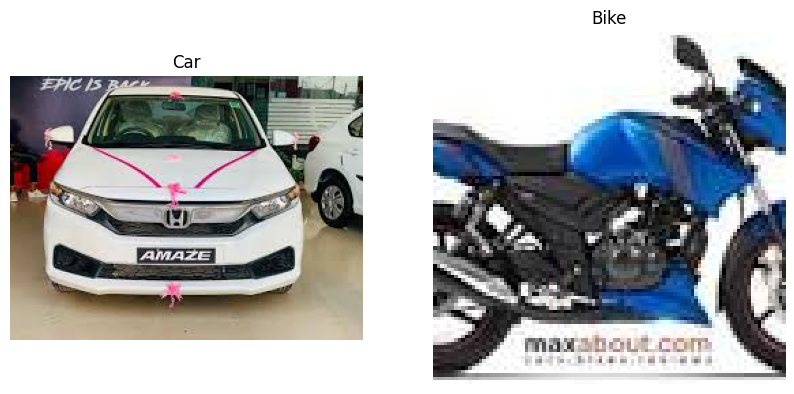

In [5]:
import random
import matplotlib.pyplot as plt
from PIL import Image

car_img = random.choice(os.listdir(car_path))
bike_img = random.choice(os.listdir(bike_path))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(Image.open(os.path.join(car_path, car_img)))
plt.title("Car")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(Image.open(os.path.join(bike_path, bike_img)))
plt.title("Bike")
plt.axis("off")

plt.show()

In [6]:
from PIL import Image

car_sample = os.path.join(car_path, os.listdir(car_path)[0])
bike_sample = os.path.join(bike_path, os.listdir(bike_path)[0])

print("Car Size :", Image.open(car_sample).size)
print("Bike Size:", Image.open(bike_sample).size)

Car Size : (300, 168)
Bike Size: (960, 368)


In [10]:
dataset_path = "/kaggle/input/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/Car-Bike-Dataset"

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [12]:
train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 3200 images belonging to 2 classes.


In [32]:
val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 800 images belonging to 2 classes.


In [14]:
print(train_gen.class_indices)

{'Bike': 0, 'Car': 1}


In [15]:
images, labels = next(train_gen)

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32,)


In [16]:
print(images.min())
print(images.max())

0.0
1.0


In [19]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

model = Sequential([
    
    Input(shape=(224,224,3)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

In [20]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(train_gen,validation_data=val_gen,epochs=10)

Epoch 1/10
  4/100 ━━━━━━━━━━━━━━━━━━━━ 3:19 2s/step - accuracy: 0.5924 - loss: 1.2348

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


100/100 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/step - accuracy: 0.7303 - loss: 0.5650 - val_accuracy: 0.8263 - val_loss: 0.3940
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.8675 - loss: 0.3240 - val_accuracy: 0.8338 - val_loss: 0.4015
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.8875 - loss: 0.2731 - val_accuracy: 0.8800 - val_loss: 0.3082
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.9006 - loss: 0.2366 - val_accuracy: 0.8938 - val_loss: 0.2834
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.9137 - loss: 0.2059 - val_accuracy: 0.8975 - val_loss: 0.2744
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.9203 - loss: 0.1998 - val_accuracy: 0.8950 - val_loss: 0.2658
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.9269 - loss: 0.1927 - val_accuracy: 0.8975 - val_loss: 0.2481
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9262 - loss: 0.1832 - val_accuracy: 0.902

In [25]:
loss, acc = model.evaluate(val_gen)
print("Accuracy:", acc)

11/25 ━━━━━━━━━━━━━━━━━━━━ 11s 833ms/step - accuracy: 0.8859 - loss: 0.2594

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 830ms/step - accuracy: 0.9075 - loss: 0.2429
Accuracy: 0.9075000286102295


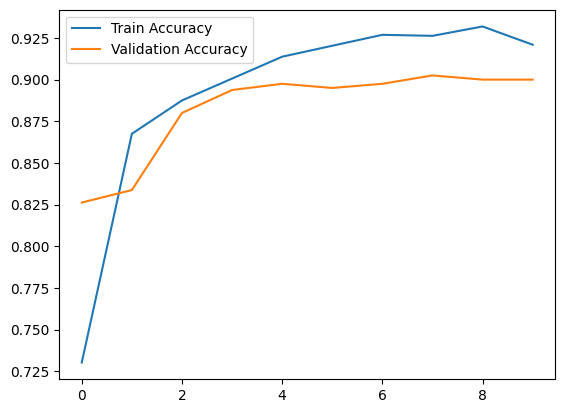

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

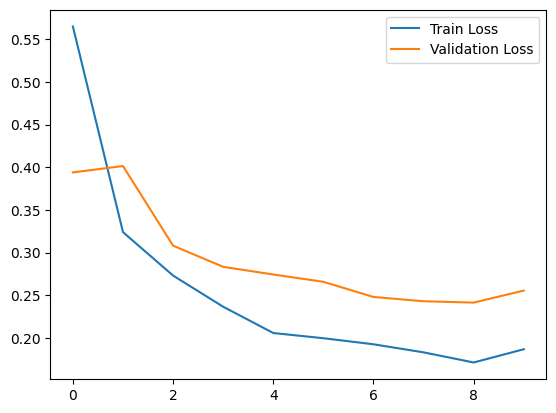

In [27]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [29]:
print("Train Accuracy :", history.history['accuracy'][-1])
print("Validation Accuracy :", history.history['val_accuracy'][-1])

Train Accuracy : 0.9209374785423279
Validation Accuracy : 0.8999999761581421


In [33]:
pred_probs = model.predict(val_gen)
preds = (pred_probs > 0.5).astype(int).flatten()

11/25 ━━━━━━━━━━━━━━━━━━━━ 11s 826ms/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 813ms/step


In [34]:
from sklearn.metrics import accuracy_score

print(accuracy_score(val_gen.classes,preds))

0.905


In [35]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print(confusion_matrix(val_gen.classes, preds))

print(classification_report(val_gen.classes,preds,target_names=['Bike','Car']))

[[346  54]
 [ 22 378]]
              precision    recall  f1-score   support

        Bike       0.94      0.86      0.90       400
         Car       0.88      0.94      0.91       400

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.90       800
weighted avg       0.91      0.91      0.90       800

